In [1]:
from pathlib import Path
import pandas as pd

DATA_PATH = (
    Path("../data/processed")
    / "binary_training_sample.csv"
)

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)

print("\nDistribution:")
print(df["Attack"].value_counts())

print("\nPercentage:")
print(
    df["Attack"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Shape: (300000, 71)

Distribution:
Attack
0    250369
1     49631
Name: count, dtype: int64

Percentage:
Attack
0    83.46
1    16.54
Name: proportion, dtype: float64


In [4]:
from pathlib import Path
import pandas as pd

DATA_PATH = (
    Path("../data/processed")
    / "binary_training_sample.csv"
)

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("\nMemory usage:")
print(
    df.memory_usage(deep=True).sum()
    / (1024 ** 2),
    "MB"
)

Dataset shape: (300000, 71)

Memory usage:
162.50622940063477 MB


In [2]:
X = df.drop(
    columns=["Attack"]
)

y = df["Attack"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (300000, 70)
y shape: (300000,)


In [5]:
print(
    X.dtypes.value_counts()
)

int64      46
float64    24
Name: count, dtype: int64


In [6]:
print(
    "Total missing values:",
    X.isnull().sum().sum()
)

Total missing values: 0


In [7]:
import numpy as np

print(
    "Total infinite values:",
    np.isinf(X).sum().sum()
)

Total infinite values: 0


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


print("Training shape:")
print(X_train.shape)

print("\nTesting shape:")
print(X_test.shape)


print("\nTraining distribution:")
print(
    y_train.value_counts()
)

print(
    y_train.value_counts(
        normalize=True
    ).mul(100).round(2)
)




print("\nTesting distribution:")
print(
    y_test.value_counts()
)

print(
    y_test.value_counts(
        normalize=True
    ).mul(100).round(2)
)

Training shape:
(240000, 70)

Testing shape:
(60000, 70)

Training distribution:
Attack
0    200295
1     39705
Name: count, dtype: int64
Attack
0    83.46
1    16.54
Name: proportion, dtype: float64

Testing distribution:
Attack
0    50074
1     9926
Name: count, dtype: int64
Attack
0    83.46
1    16.54
Name: proportion, dtype: float64


#### Scaling 

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [10]:
baseline_model = Pipeline(
    steps=[
        (
            "scaler",
            StandardScaler()
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

In [12]:
print("Training Logistic Regression...")

baseline_model.fit(
    X_train,
    y_train
)

print("Training complete.")

Training Logistic Regression...
Training complete.


In [13]:
y_pred = baseline_model.predict(
    X_test
)

In [14]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

print(
    f"Accuracy : {accuracy:.4f}"
)

print(
    f"Precision: {precision:.4f}"
)

print(
    f"Recall   : {recall:.4f}"
)

print(
    f"F1 Score : {f1:.4f}"
)

Accuracy : 0.9565
Precision: 0.8773
Recall   : 0.8566
F1 Score : 0.8669


In [15]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "BENIGN",
            "ATTACK"
        ],
        digits=4
    )
)

              precision    recall  f1-score   support

      BENIGN     0.9717    0.9763    0.9740     50074
      ATTACK     0.8773    0.8566    0.8669      9926

    accuracy                         0.9565     60000
   macro avg     0.9245    0.9164    0.9204     60000
weighted avg     0.9561    0.9565    0.9563     60000



In [16]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[48885  1189]
 [ 1423  8503]]


In [17]:
from pathlib import Path

REPORT_DIR = Path(
    "../reports/baseline"
)

REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

report = classification_report(
    y_test,
    y_pred,
    target_names=[
        "BENIGN",
        "ATTACK"
    ],
    digits=4
)

with open(
    REPORT_DIR /
    "logistic_regression_baseline.txt",
    "w"
) as f:

    f.write(
        "Binary Logistic Regression Baseline\n"
    )

    f.write(
        "=" * 50 + "\n\n"
    )

    f.write(
        f"Dataset size: {len(df):,}\n"
    )

    f.write(
        f"Training size: {len(X_train):,}\n"
    )

    f.write(
        f"Testing size: {len(X_test):,}\n\n"
    )

    f.write(
        f"Accuracy: {accuracy:.4f}\n"
    )

    f.write(
        f"Precision: {precision:.4f}\n"
    )

    f.write(
        f"Recall: {recall:.4f}\n"
    )

    f.write(
        f"F1: {f1:.4f}\n\n"
    )

    f.write(report)

print("Baseline report saved.")

Baseline report saved.


In [18]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

weighted_model = Pipeline(
    steps=[
        (
            "scaler",
            StandardScaler()
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

print("Class-weighted model created.")

Class-weighted model created.


In [19]:
print("Training class-weighted Logistic Regression...")

weighted_model.fit(
    X_train,
    y_train
)

print("Training complete.")

Training class-weighted Logistic Regression...
Training complete.


In [20]:
y_pred_weighted = weighted_model.predict(
    X_test
)

In [21]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

weighted_accuracy = accuracy_score(
    y_test,
    y_pred_weighted
)

weighted_precision = precision_score(
    y_test,
    y_pred_weighted
)

weighted_recall = recall_score(
    y_test,
    y_pred_weighted
)

weighted_f1 = f1_score(
    y_test,
    y_pred_weighted
)

print(
    f"Accuracy : {weighted_accuracy:.4f}"
)

print(
    f"Precision: {weighted_precision:.4f}"
)

print(
    f"Recall   : {weighted_recall:.4f}"
)

print(
    f"F1 Score : {weighted_f1:.4f}"
)

Accuracy : 0.9378
Precision: 0.7337
Recall   : 0.9791
F1 Score : 0.8389


In [22]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_weighted,
        target_names=[
            "BENIGN",
            "ATTACK"
        ],
        digits=4
    )
)

              precision    recall  f1-score   support

      BENIGN     0.9956    0.9296    0.9614     50074
      ATTACK     0.7337    0.9791    0.8389      9926

    accuracy                         0.9378     60000
   macro avg     0.8647    0.9544    0.9001     60000
weighted avg     0.9523    0.9378    0.9412     60000



In [23]:
from sklearn.metrics import confusion_matrix

weighted_cm = confusion_matrix(
    y_test,
    y_pred_weighted
)

print(weighted_cm)

[[46547  3527]
 [  207  9719]]


In [24]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Class-Weighted Logistic Regression"
    ],
    "Accuracy": [
        accuracy,
        weighted_accuracy
    ],
    "Precision": [
        precision,
        weighted_precision
    ],
    "Recall": [
        recall,
        weighted_recall
    ],
    "F1": [
        f1,
        weighted_f1
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.956467,0.877322,0.856639,0.866857
1,Class-Weighted Logistic Regression,0.937767,0.733731,0.979146,0.838857


In [25]:
REPORT_DIR = Path(
    "../reports/baseline"
)

REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

weighted_report = classification_report(
    y_test,
    y_pred_weighted,
    target_names=[
        "BENIGN",
        "ATTACK"
    ],
    digits=4
)

with open(
    REPORT_DIR /
    "logistic_regression_class_weighted.txt",
    "w"
) as f:

    f.write(
        "Binary Class-Weighted Logistic Regression\n"
    )

    f.write(
        "=" * 50 + "\n\n"
    )

    f.write(
        f"Accuracy: {weighted_accuracy:.4f}\n"
    )

    f.write(
        f"Precision: {weighted_precision:.4f}\n"
    )

    f.write(
        f"Recall: {weighted_recall:.4f}\n"
    )

    f.write(
        f"F1: {weighted_f1:.4f}\n\n"
    )

    f.write(weighted_report)

print("Weighted model report saved.")

Weighted model report saved.


##Add new Non-Linear Model...

In [26]:
from sklearn.ensemble import RandomForestClassifier

In [27]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_leaf=2,
    class_weight=None,
    random_state=42,
    n_jobs=2
)

print("Random Forest created.")

Random Forest created.


In [28]:
print("Training Random Forest...")

rf_model.fit(
    X_train,
    y_train
)

print("Random Forest training complete.")

Training Random Forest...
Random Forest training complete.


In [29]:
y_pred_rf = rf_model.predict(
    X_test
)

In [30]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

rf_precision = precision_score(
    y_test,
    y_pred_rf
)

rf_recall = recall_score(
    y_test,
    y_pred_rf
)

rf_f1 = f1_score(
    y_test,
    y_pred_rf
)

print(
    f"Accuracy : {rf_accuracy:.4f}"
)

print(
    f"Precision: {rf_precision:.4f}"
)

print(
    f"Recall   : {rf_recall:.4f}"
)

print(
    f"F1 Score : {rf_f1:.4f}"
)

Accuracy : 0.9985
Precision: 0.9966
Recall   : 0.9945
F1 Score : 0.9955


In [31]:
print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=[
            "BENIGN",
            "ATTACK"
        ],
        digits=4
    )
)

              precision    recall  f1-score   support

      BENIGN     0.9989    0.9993    0.9991     50074
      ATTACK     0.9966    0.9945    0.9955      9926

    accuracy                         0.9985     60000
   macro avg     0.9977    0.9969    0.9973     60000
weighted avg     0.9985    0.9985    0.9985     60000



In [32]:
from sklearn.metrics import confusion_matrix

rf_cm = confusion_matrix(
    y_test,
    y_pred_rf
)

print(rf_cm)

[[50040    34]
 [   55  9871]]


In [33]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Weighted Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        weighted_accuracy,
        rf_accuracy
    ],
    "Attack Precision": [
        precision,
        weighted_precision,
        rf_precision
    ],
    "Attack Recall": [
        recall,
        weighted_recall,
        rf_recall
    ],
    "Attack F1": [
        f1,
        weighted_f1,
        rf_f1
    ]
})

comparison

,Model,Accuracy,Attack Precision,Attack Recall,Attack F1
0,Logistic Regression,0.956467,0.877322,0.856639,0.866857
1,Weighted Logistic Regression,0.937767,0.733731,0.979146,0.838857
2,Random Forest,0.998517,0.996567,0.994459,0.995512


In [34]:
from sklearn.metrics import confusion_matrix

rf_cm = confusion_matrix(
    y_test,
    y_pred_rf
)

print(rf_cm)

[[50040    34]
 [   55  9871]]


In [35]:
tn, fp, fn, tp = rf_cm.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

True Negatives : 50040
False Positives: 34
False Negatives: 55
True Positives : 9871


In [36]:
false_positive_rate = fp / (fp + tn)

false_negative_rate = fn / (fn + tp)

print(
    f"False Positive Rate: "
    f"{false_positive_rate:.6f}"
)

print(
    f"False Negative Rate: "
    f"{false_negative_rate:.6f}"
)

False Positive Rate: 0.000679
False Negative Rate: 0.005541


In [37]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(
    feature_importance.head(20)
)

                        Feature  Importance
13        Bwd_Packet_Length_Std    0.094490
12       Bwd_Packet_Length_Mean    0.075386
40       Packet_Length_Variance    0.061310
50          Average_Packet_Size    0.052218
5   Total_Length_of_Bwd_Packets    0.046515
52         Avg_Bwd_Segment_Size    0.046195
37            Max_Packet_Length    0.044506
38           Packet_Length_Mean    0.039218
39            Packet_Length_Std    0.038534
10        Bwd_Packet_Length_Max    0.037844
0              Destination_Port    0.028722
54          Subflow_Fwd_Packets    0.026594
2             Total_Fwd_Packets    0.023785
4   Total_Length_of_Fwd_Packets    0.021283
57            Subflow_Bwd_Bytes    0.020411
55            Subflow_Fwd_Bytes    0.016091
61         min_seg_size_forward    0.015758
33            Bwd_Header_Length    0.014905
6         Fwd_Packet_Length_Max    0.014065
60             act_data_pkt_fwd    0.013947


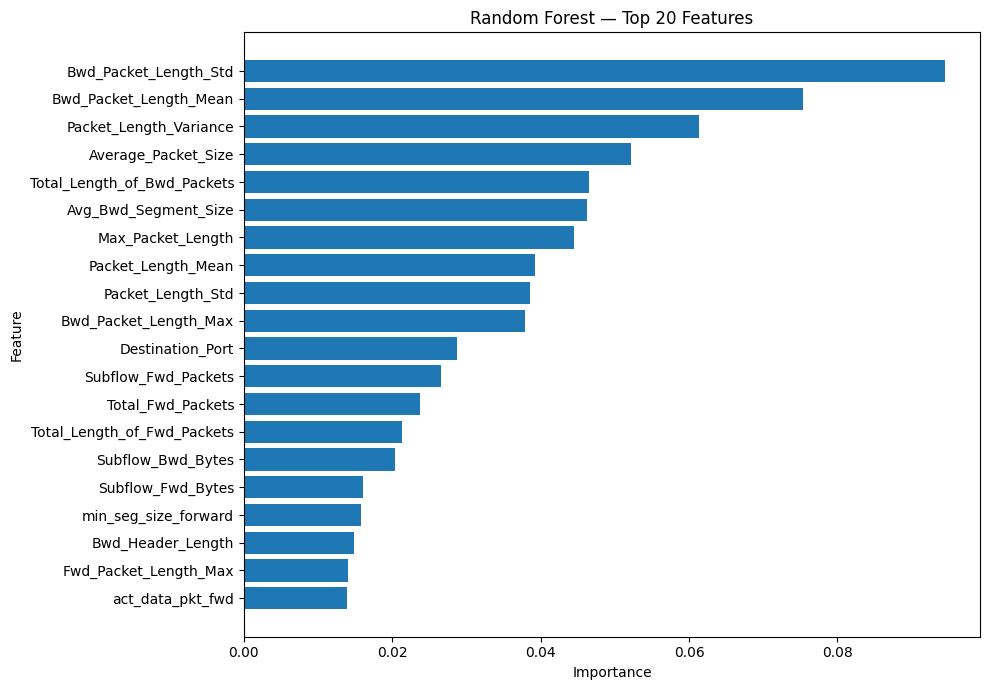

In [38]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(20)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest — Top 20 Features")

plt.tight_layout()

plt.show()

In [39]:
from pathlib import Path

REPORT_DIR = Path(
    "../reports/baseline"
)

REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

feature_importance.to_csv(
    REPORT_DIR /
    "random_forest_feature_importance.csv",
    index=False
)

print("Feature importance saved.")

Feature importance saved.


In [ ]:
from pathlib import Path
import joblib

MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODEL_DIR / "random_forest_binary.joblib"

joblib.dump(
    rf_model,
    MODEL_PATH
)

print(f"Random Forest saved to: {MODEL_PATH}")

Random Forest saved to: ..\models\random_forest_binary.joblib


: 